## Tool Creation and Calling
- LLM Decides to use an external function/tool when it needs additional information perform an action, instead of answering only from  
  its knowledge.
- Any Python Function can be coverted into Tool

    ```text
User: "What is current stock price of Mahindra Motors"

    ↓
LLM decides: "I need to get live stock price of Mahindra Motors"

    ↓
Calls NSE Tool

    ↓
Tool returns: 1200\-  per stock

    ↓
LLM gives final answer
    ```text

- Node: It is python Function which is executed by graph. Which is deterministic workflow.
- Tool: LLM decides when to call tool (googl email MCP etc). which is dynamic workflow.
- The LLM does not execute the function itself. It decides which tool(function) to call and with what arguments; your application executes the tool and returns the result to the LLM.


***Tool Creation***
- Different Ways of Tool Creation

## 1. @tool Decorator##

In [1]:
from langchain_core.tools import tool

In [3]:
@tool
def add_numbers(a: int, b: int) -> int:
    """Add two numbers together."""   #This is description of tool.
    return a + b

In [4]:
print ("Name:", add_numbers.name)
print ("Description:", add_numbers.description)
print ("Args:" , add_numbers.args)

Name: add_numbers
Description: Add two numbers together.
Args: {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


In [10]:
result=add_numbers.invoke({"a": 20, "b": 30})
print ("Result:", result)

Result: 50


## 2. @tool("custom_name")##

- Custom naming is supported for tools.

In [7]:
@tool("Tool:Addition Of Numbers")
def add_numbers_with_custom_name(a: int, b: int) -> int:
    """Add two numbers together."""   #This is description of tool.
    return a + b

print ("Name:", add_numbers_with_custom_name.name)
print ("Description:", add_numbers_with_custom_name.description)
print("Result:", add_numbers_with_custom_name.invoke({"a": 20, "b": 30}))

Name: Tool:Addition Of Numbers
Description: Add two numbers together.
Result: 50


## 3. @tool(return_direct=True)

- Once After result Tool Execution will be stopped and Dont neccessarily needs LLM to process Tool Result Again.

In [11]:
@tool(return_direct=True)
def get_wishes_message(name: str) -> str:
    """Get a wishes message for a given name."""
    return f"Hello {name}, Good Morning!"
print("ToolDescription:",get_wishes_message.description)
print ("Check Return Direct Value:",get_wishes_message.return_direct)
print ("Output:", get_wishes_message.invoke({"name": "Anil Pomar"}))

ToolDescription: Get a wishes message for a given name.
Check Return Direct Value: True
Output: Hello Anil Pomar, Good Morning!


## 4. @Tool with pydantic

- Tool with defined Schema.
- It is widely used in Industry.
- To make any class Pydantic Class we need to inherit BaseModel.
- pydantic class validates the type of data passed to class. And Exception Raised in case of data and its datatype mismatch.

In [13]:
from pydantic import BaseModel, Field, ValidationError

class CustomerTool(BaseModel):
    name: str=Field(..., description="Name of the customer")
    Age: int=Field(..., description="Age of the customer")

In [17]:
@tool (args_schema=CustomerTool)
def get_customer_details(name: str, Age: int) -> str:
    """Get customer details."""
    return f"Customer Name: {name}, Age: {Age}"

In [21]:
print("Customer Details", get_customer_details.invoke({"name": "Anil Pomar", "Age": 30}))

Customer Details Customer Name: Anil Pomar, Age: 30


In [23]:
print("Customer Details", get_customer_details.invoke({"name": 9, "Age": "30"}))

ValidationError: 1 validation error for CustomerTool
name
  Input should be a valid string [type=string_type, input_value=9, input_type=int]
    For further information visit https://errors.pydantic.dev/2.13/v/string_type

## 5. @Tool (parse_docstring=True)

- Usually Docstring in python generates metadata for the tool, like its description, 
- If parse_docstring=True make the LLM then sees this tool information and can make a better decision what and when to use tool.
- The docstring doesn't change what the Python function actually does. It mainly improves the tool's metadata/schema exposed to the agent.

In [29]:
@tool(parse_docstring=True)
def search_with_docstring(query:str,limit:int) -> str:
   """Search documents.

    Args:
        query: Search query entered by the user.
        limit: Maximum number of results.
    """
   return f"Searching for '{query}' with limit = {limit}"

print ("Args Schema")
print(search_with_docstring.args_schema.model_json_schema())

Args Schema
{'description': 'Search documents.', 'properties': {'query': {'description': 'Search query entered by the user.', 'title': 'Query', 'type': 'string'}, 'limit': {'description': 'Maximum number of results.', 'title': 'Limit', 'type': 'integer'}}, 'required': ['query', 'limit'], 'title': 'search_with_docstring', 'type': 'object'}


In [30]:
print("Executing Search Doc String:",search_with_docstring.invoke({"query":"LangGraph Memory","limit":4}))

Executing Search Doc String: Searching for 'LangGraph Memory' with limit = 4


## 6. Async Fucntiobn with @Tool

- Asynct makes Tool Asynchronous 
- This is Used when Tool make - Calling Rest API's, Databases,Websearches, MCP Tool Calls 

In [31]:
import asyncio
@tool
async def get_data_async(url:str) ->str:
    """Fetch data Asysnchronosly"""
    await asyncio.sleep(0.1)
    return f"Data from{url}"

In [35]:
result= await get_data_async.ainvoke({"url":"https://demo.com"})
print ("Asysnchronous Tool Result:",result)

Asysnchronous Tool Result: Data fromhttps://demo.com


## 7. Tool with runtime ##
- ToolRuntime gives a tool access to the runtime context of the agent execution.
- ToolRuntime change tool calling during runtime.
- ***runtime*** is automatically injected by LangChain. LLM no need to provide it a tool argument.
- This is useful because you don't want the LLM deciding or supplying sensitive application context.
- ToolRuntime gives access to 
```text
ToolRuntime
   │
   ├── context
   ├── state
   ├── store
   ├── stream_writer
   └── config
```text

In [36]:
from langchain.tools import tool, ToolRuntime

@tool
def get_user_orders(runtime:ToolRuntime):
    """Get ORder for the current user"""

    user_id=runtime.context.user_id

    return f"Getting orders from User{user_id}"

In [38]:
from dataclasses import dataclass

@dataclass
class CustomerContext:
    user_id: str
    tenant_id: str

In [39]:
@tool
def get_customer(runtime:ToolRuntime[CustomerContext]):
    """Get Customer Details from Customer Context"""

    user_id=runtime.context.user_id
    tentant_id=runtime.context.tenant_id

    return f"Retrieved Customer UserId {user_id} & Tentant Id {tentant_id}"

## 8. Tool(...) - Constructor

- This is Constructor notation in python
- Here You have to create constructor for yourself.
- By just using ***@tool*** in this case constructor is created by default.
- ***Tool.from_function(...)*** is a programmatic factory method that creates a LangChain Tool from a Python function. Using This No need to explicitly use @Tool on python Function. It converts normal Python to Tool from 'func' parameter passed inside Tool.from_function.
- ***Tool.from_function()*** is essentially used when function has one input parameter and structedTool.from_function is used when function has more than one input parameter and it has lot more advantages discussed after this concept.

**#Default Constructor**

In [ ]:
#Default Constructor

from langchain_core.tools import Tool

def simple_search_function(query:str)->str:
    return f"Searching for Query {query}"

print("Output:",simple_search_function("Who Am I"))

Output: Searching for Query Who Am I


**#Explicit Constructor**

In [44]:
#Explicit Constructor

from langchain_core.tools import Tool


#How Too With Constructor looks like 

simple_tool=Tool(
    name="Tool_Constructor",
    func= simple_search_function,
    description= "Simple Search Function"
)

print("Name:",simple_tool.name)
print("Execution Result:", simple_tool.invoke("Tool with Constructor"))

Name: Tool_Constructor
Execution Result: Searching for Query Tool with Constructor


**# One Other way Creating Constructor for Tool**

In [46]:
# One Other way Creating Constructor for Tool

from langchain_core.tools import Tool

def search_function(query:str):
    """Simple Search Function"""
    return(f"It Search function {query}")

simple_search_Tool=Tool.from_function(
    name="Search_Tool",
    func=search_function,
    description="Tool Used for Search Function"
)

print("Calling Search function using Tool.From_function",simple_search_Tool.invoke("Using Tool.from_function"))

Calling Search function using Tool.From_function It Search function Using Tool.from_function


In [47]:
Tool.from_function(
    func=search_function,
    name="search_from_function",
    description="Search information.",
)

Tool(name='search_from_function', description='Search information.', func=<function search_function at 0x000001D0483A3F60>)

## 9.StructredTool.from_function()

- ***StructuredTool.from_function()*** is used when you want to create a LangChain tool from a Python function with a structured input schema.
- Function Signature cane be represented as a structured input schema to LLM.
- For Example: 

    def search_orders(customer_id, status, limit):

    with sturcturedTool.from_function LLM will get schema in below format(which is structured)
    {
  "customer_id": "C123",
  "status": "shipped",
  "limit": 10
    }


In [3]:
from langchain_core.tools import StructuredTool

def calculate_tax_test(income:float,tax_rate:float)->float:
    return income * tax_rate

tax_rate_tool=StructuredTool.from_function(
    func=calculate_tax_test,
    name="Calcualte_Tax_tool",
    description="Calculate Tax for income Tax"    
)

print("Args:", tax_rate_tool.args)
print("Tax Result:",tax_rate_tool.invoke({"income":10000,"tax_rate":4}) )


Args: {'income': {'title': 'Income', 'type': 'number'}, 'tax_rate': {'title': 'Tax Rate', 'type': 'number'}}
Tax Result: 40000.0


## 10. Using Pydantic Schema with StructuredTool.From_Function**

- For More Control
- Richer Schema
- Which helps LLM generate correctly structured tool calls
```text
search_orders
       │
       ▼
OrderSearchInput
       │
       ├── _id → Customer ID
       ├── status      → Order status
       └── limit       → Maximum number
```text

In [13]:
from pydantic import BaseModel,Field
from langchain_core.tools import StructuredTool

class OrderSearchInput(BaseModel):
    id:str=Field(display="Customer Id")
    status:str=Field(display="Order Status")
    limit:int=Field(display="Maximum Number")


def search_orders(
    id: str,
    status: str,
    limit: int
)-> dict:
    return {"id": id, "status": status, "limit": limit}

order_tool=StructuredTool.from_function(
    func=search_orders,
    name="Order_search_Tool",
    description="Order Search Tool with Pydantic and StructuredTool Function",
    args_schema=OrderSearchInput
)

result=order_tool.invoke({"id":"Anil","status":"Ordered","limit":4})
print("Order Tool Results:",result["id"], result["status"], result["limit"])


Order Tool Results: Anil Ordered 4


C:\Users\anilp\AppData\Local\Temp\ipykernel_32624\681756905.py:5: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'display'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  id:str=Field(display="Customer Id")
C:\Users\anilp\AppData\Local\Temp\ipykernel_32624\681756905.py:6: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'display'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  status:str=Field(display="Order Status")
C:\Users\anilp\AppData\Local\Temp\ipykernel_32624\681756905.py:7: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Ex

## 11. Creating Tool Using BaseTool class

- BaseTool is langchain's foundational abstraction for tools.  Tools,StructuredTool are concrete implementations built on top of it.
- @Tool is convenient way to create tools from Python functions.
- Use BaseTool when you need to build a reusable custom tool class with its own configuration, state, validation, sync/async behavior, error handling, database/API clients, logging, etc.
- It is gives more control to create Custom Custom Behavior.
```text
                    BaseTool
                       │
              ┌────────┴────────┐
              │                 │
            Tool        StructuredTool
              │                 │
       Tool.from_function   StructuredTool.from_function
              │                 │
              └───────┬─────────┘
                      │
                  @tool
            (convenient decorator)
```text

In [25]:
from typing import Type
from langchain_core.tools import BaseTool

class SearchInputTest(BaseModel):
    query:str=Field(description="Search Query")

class MySearchToolTest(BaseTool):
    name:str="My search"
    description:str="Search my database"
    args_schema:Type[BaseTool]=SearchInputTest

    def _run(self,query:str)->str:
        return f"Custom database result for :{query}"

custom_base_tool=MySearchToolTest()

print("Execution result:", custom_base_tool.invoke({
    "query": "LangGraph state management"
}))


Execution result: Custom database result for :LangGraph state management


**What do BaseModel And BaseTool do in above Example**

- class SearchInputTest(BaseModel):   # 1. You use it explicitly, as the input contract
- class MySearchToolTest(BaseTool):   # 2. BaseTool inherits from BaseModel, so your tool is a model too

- This One Class (class SearchInputTest(BaseModel)) does 3 things
    a)Tell the LLM how to call the Tool(JSON Schema).LangChain converts the model into JSON Schema and sends it to the LLM:

    b)Validates the LLM's arguments before your code runs
    c) Converts types and enforces rules (If any Like below)
    
    class SearchInputTest(BaseModel):
    query: str = Field(description="Search query text", min_length=3)
    top_k: int = Field(default=5, ge=1, le=20, description="Number of results")
    category: Literal["docs", "code", "tickets"] = Field(default="docs")
- Base Tool Itself a BaseModel
- Below Image (With And Without BaseModel)

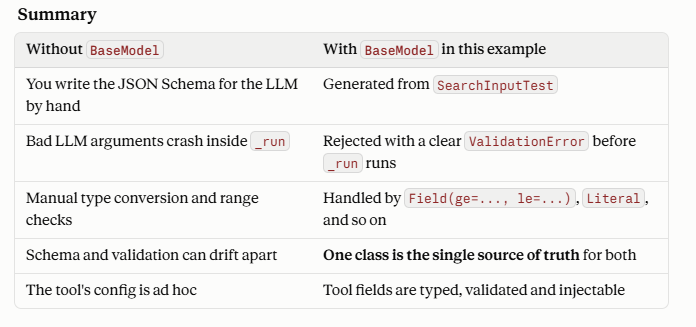

